In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import IPython.display as ipd
from scipy.io import wavfile
import glob

import sklearn

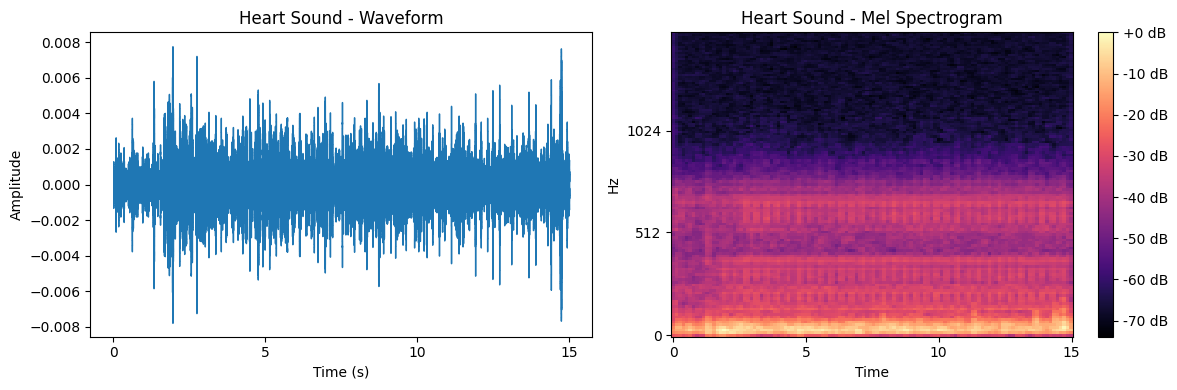

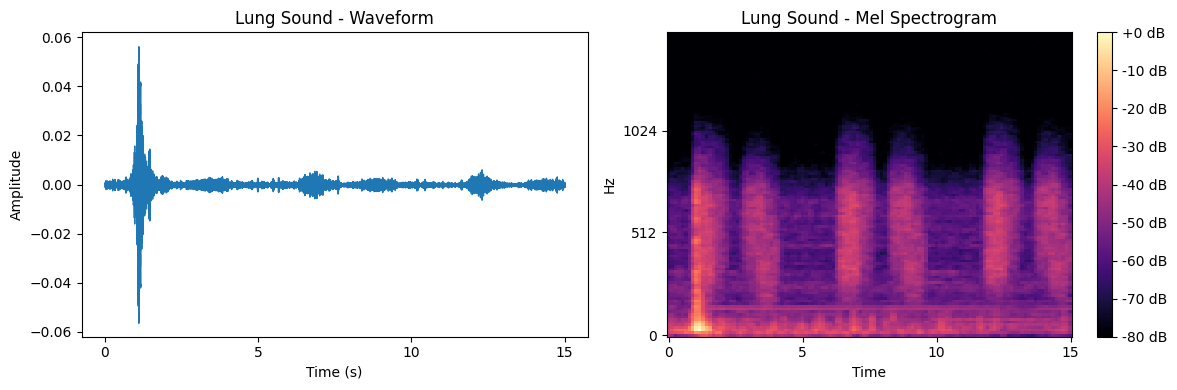

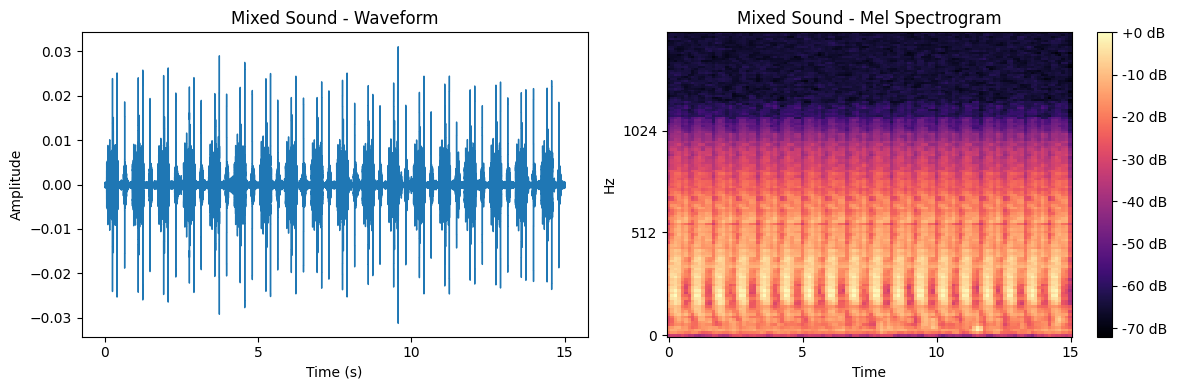

In [2]:
# Define paths to dataset folders
hs_path = "HLS-CMDS_dataset/HS/HS"
ls_path = "HLS-CMDS_dataset/LS/LS"
mix_path = "HLS-CMDS_dataset/Mix/Mix"

# Function to load and display audio samples
def load_and_display_sample(file_path, title):
    y, sr = librosa.load(file_path, sr=None)
    plt.figure(figsize=(12, 4))
    
    # Plot waveform
    plt.subplot(1, 2, 1)
    librosa.display.waveshow(y, sr=sr)
    plt.title(f"{title} - Waveform")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    
    # Plot mel spectrogram
    plt.subplot(1, 2, 2)
    S = librosa.feature.melspectrogram(y=y, sr=sr)
    S_dB = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f"{title} - Mel Spectrogram")
    
    plt.tight_layout()
    plt.show()

# Load and display samples from each folder
for folder_path, folder_name in [(hs_path, "Heart Sound"), (ls_path, "Lung Sound"), (mix_path, "Mixed Sound")]:
    # Get first wav file in folder
    wav_files = [f for f in os.listdir(folder_path) if f.endswith('.wav')]
    if wav_files:
        sample_file = os.path.join(folder_path, wav_files[0])
        load_and_display_sample(sample_file, folder_name)


In [3]:
# Import necessary libraries
import os
import csv
from scipy.io import wavfile

# Define paths
hs_path = "HLS-CMDS_dataset/HS/HS/"
ls_path = "HLS-CMDS_dataset/LS/LS/"
mix_path = "HLS-CMDS_dataset/Mix/Mix/"

# Function to load sounds based on CSV metadata
def load_sounds_from_csv(hs_csv, ls_csv, mix_csv):
    # Initialize dictionaries to store sounds
    heart_sounds = {}
    lung_sounds = {}
    mix_sounds = {}
    
    # Read the heart sounds CSV file
    with open(hs_csv, 'r') as csvfile:
        reader = csv.DictReader(csvfile)
        for row in reader:
            # Only load normal heart sounds
            if row.get('Heart Sound Type') == 'Normal':
                sound_id = row['Heart Sound ID']
                
                # Load heart sounds
                heart_file = f"{sound_id}.wav"
                heart_path = os.path.join(hs_path, heart_file)
                if os.path.exists(heart_path):
                    sample_rate, data = wavfile.read(heart_path)
                    heart_sounds[heart_file] = {
                        'data': data, 
                        'sample_rate': sample_rate,
                        'metadata': row
                    }
    
    # Read the lung sounds CSV file
    with open(ls_csv, 'r') as csvfile:
        reader = csv.DictReader(csvfile)
        for row in reader:
            # Only load normal lung sounds
            if row.get('Lung Sound Type') == 'Normal':
                sound_id = row['Lung Sound ID']
                
                # Load lung sounds
                lung_file = f"{sound_id}.wav"
                lung_path = os.path.join(ls_path, lung_file)
                if os.path.exists(lung_path):
                    sample_rate, data = wavfile.read(lung_path)
                    lung_sounds[lung_file] = {
                        'data': data, 
                        'sample_rate': sample_rate,
                        'metadata': row
                    }
    
    # Read the mixed sounds CSV file
    with open(mix_csv, 'r') as csvfile:
        reader = csv.DictReader(csvfile)
        for row in reader:
            # Only load mixes with normal heart and lung sounds
            if row.get('Heart Sound Type') == 'Normal' and row.get('Lung Sound Type') == 'Normal':
                sound_id = row['Mixed Sound ID']
                heart_id = row['Heart Sound ID']
                lung_id = row['Lung Sound ID']
                
                # Load mixed sounds
                mix_file = f"{sound_id}.wav"
                mix_path_full = os.path.join(mix_path, mix_file)
                if os.path.exists(mix_path_full):
                    sample_rate, data = wavfile.read(mix_path_full)
                    mix_sounds[mix_file] = {
                        'data': data, 
                        'sample_rate': sample_rate,
                        'metadata': row,
                        'heart_id': heart_id,
                        'lung_id': lung_id
                    }
    
    print(f"Loaded {len(heart_sounds)} normal heart sounds")
    print(f"Loaded {len(lung_sounds)} normal lung sounds")
    print(f"Loaded {len(mix_sounds)} normal mixed sounds")
    
    return heart_sounds, lung_sounds, mix_sounds

# Load the sounds from CSV
hs_csv = "HLS-CMDS_dataset/HS.csv"
ls_csv = "HLS-CMDS_dataset/LS.csv"
mix_csv = "HLS-CMDS_dataset/Mix.csv"
heart_sounds, lung_sounds, mix_sounds = load_sounds_from_csv(hs_csv, ls_csv, mix_csv)


Loaded 9 normal heart sounds
Loaded 12 normal lung sounds
Loaded 3 normal mixed sounds


Loading Heart Sound sample: M_T_LUSB.wav


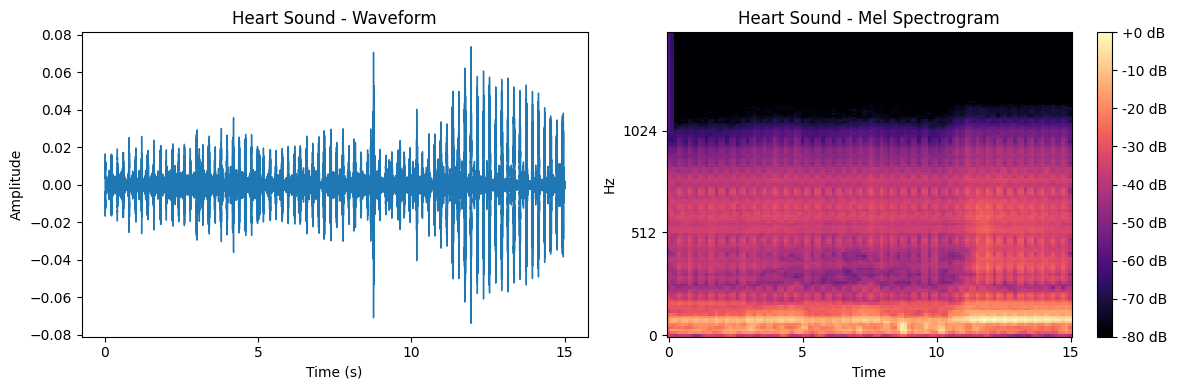

Loading Lung Sound sample: M_W_RUA.wav


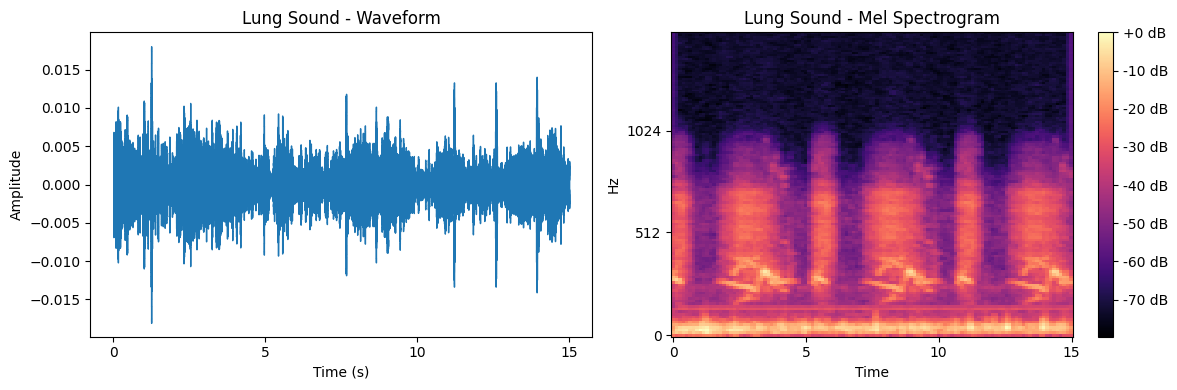

Loading Mixed Sound sample: M0046.wav


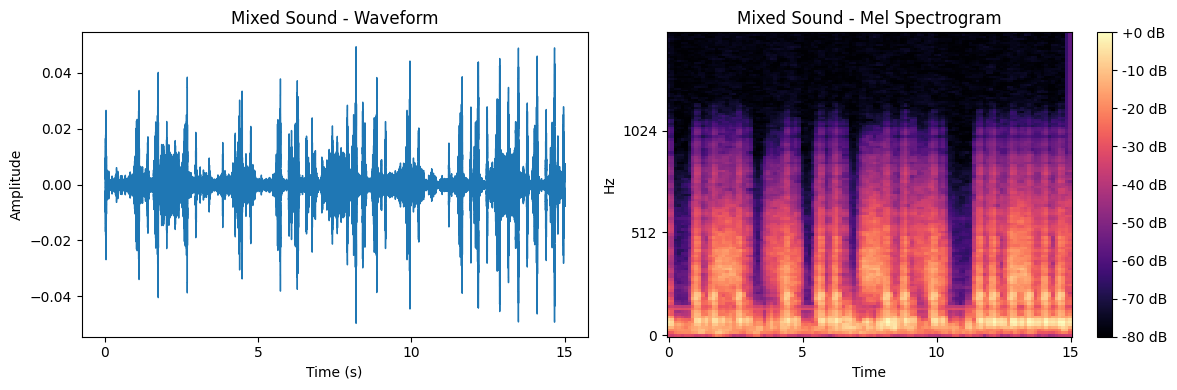

In [4]:
# Load, display, and play the first file from each section
def plot_first_files():
    for folder_path, folder_name in [(hs_path, "Heart Sound"), (ls_path, "Lung Sound"), (mix_path, "Mixed Sound")]:
        wav_files = [f for f in os.listdir(folder_path) if f.endswith('.wav')]
        if wav_files:
            sample_file = os.path.join(folder_path, wav_files[-1])
            print(f"Loading {folder_name} sample: {wav_files[-1]}")
            load_and_display_sample(sample_file, folder_name)
            
            # Play the audio
            display(ipd.Audio(sample_file))

# Execute the function
plot_first_files()


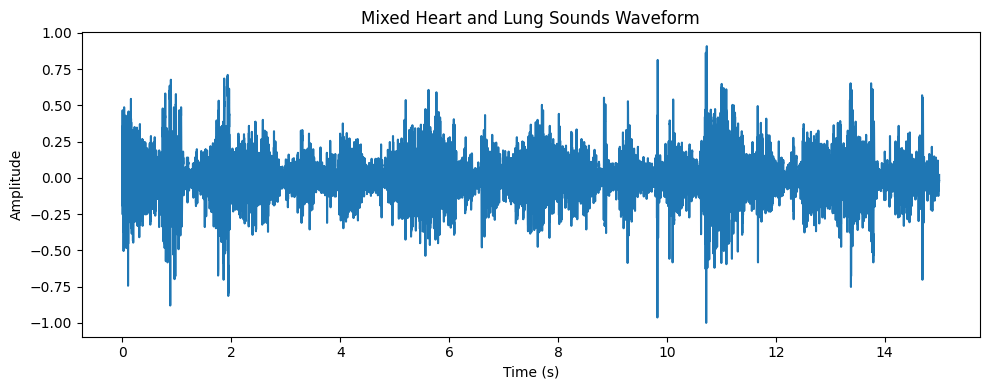

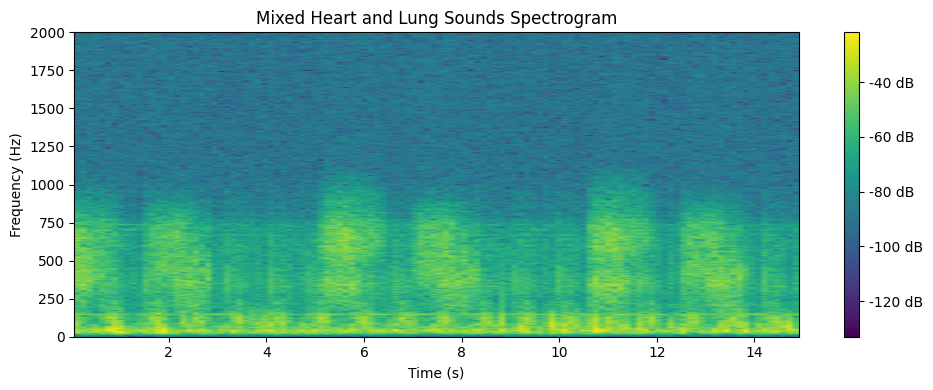

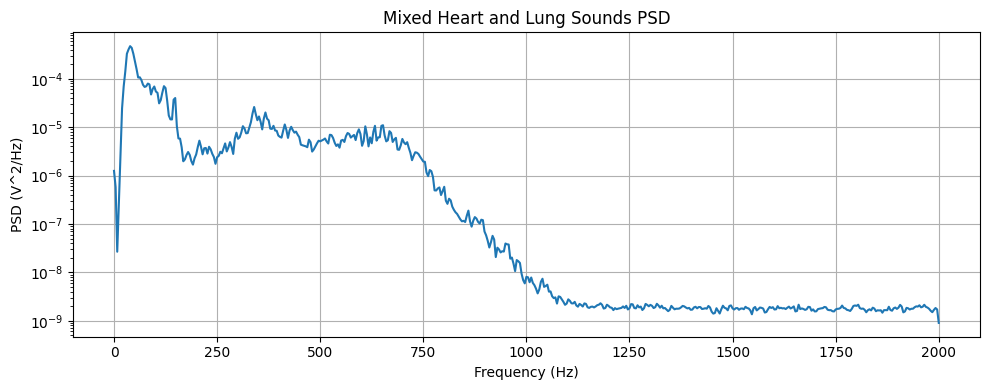

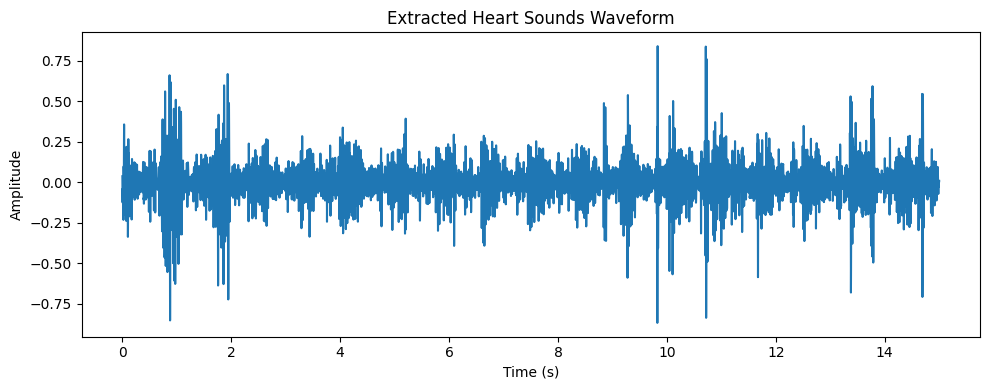

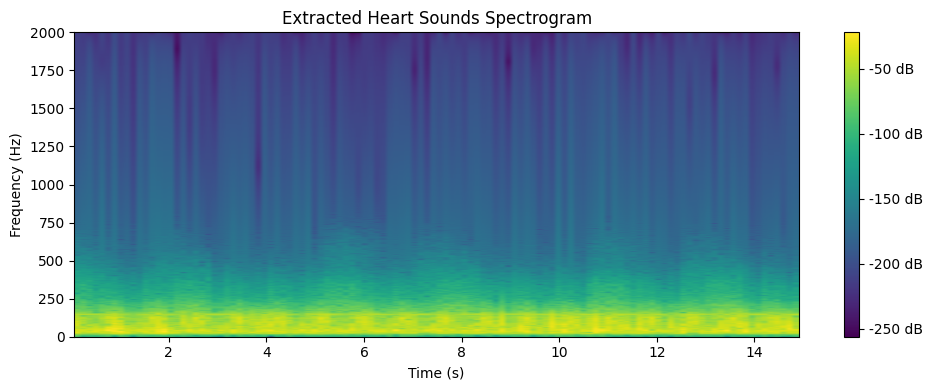

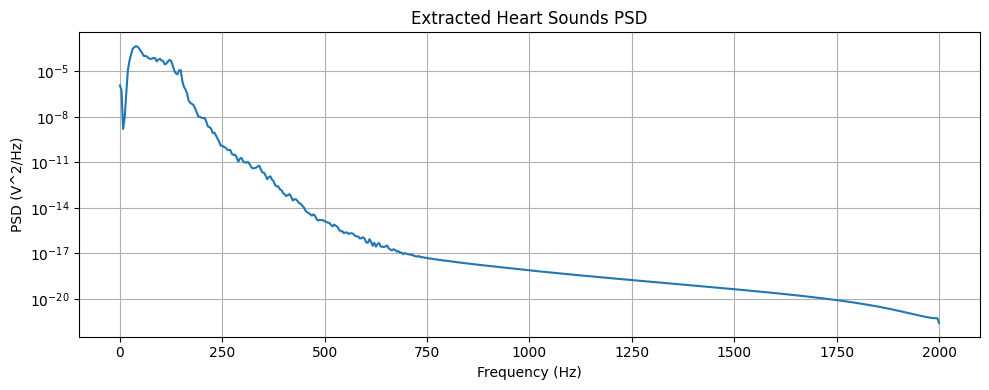

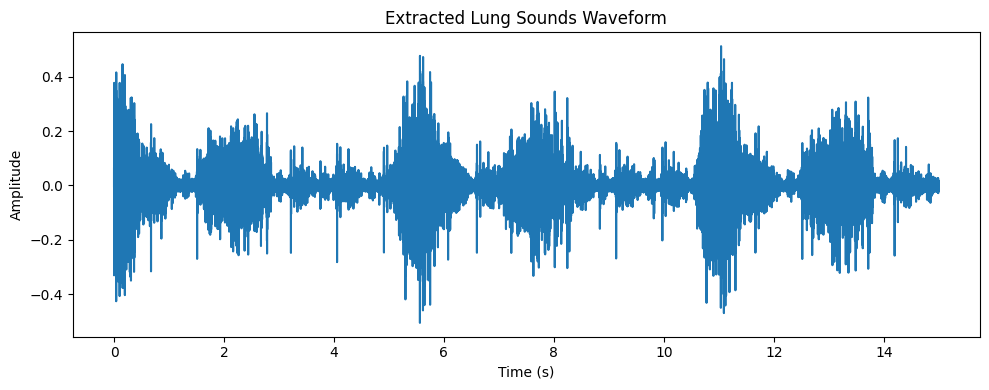

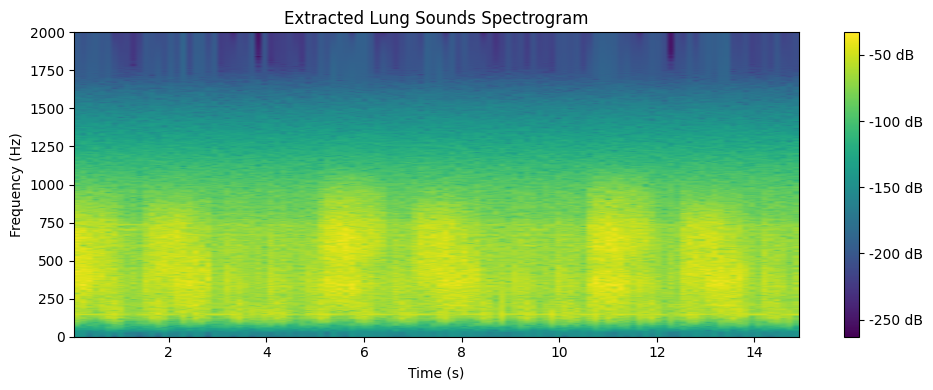

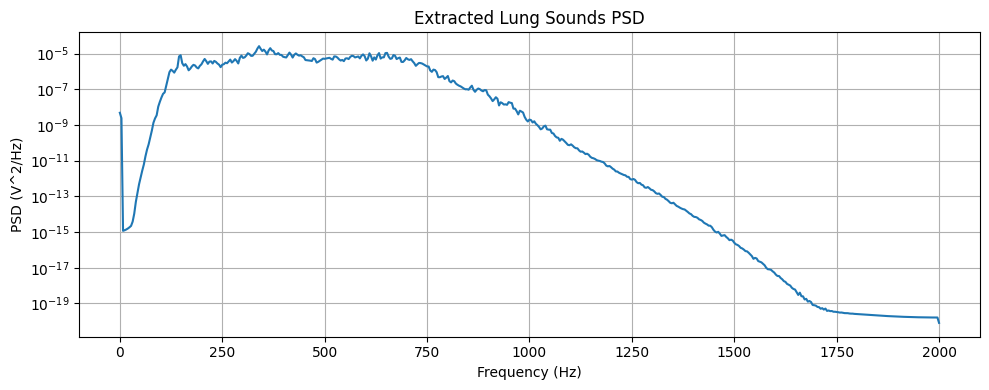

Heart Sound:


Lung Sound:


In [5]:
# Load the mixed heart and lung sounds
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
import IPython.display as ipd
from scipy.signal import butter, filtfilt, welch

# Function to load audio file
def load_audio_file(file_path):
    sr, data = wavfile.read(file_path)
    return data / np.max(np.abs(data)), sr  # Normalize to [-1, 1] using max absolute value

# Functions to display audio data
def display_waveform(y, sr, title="Waveform"):
    plt.figure(figsize=(10, 4))
    plt.plot(np.arange(len(y)) / sr, y)
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()

def display_spectrogram(y, sr, title="Spectrogram"):
    plt.figure(figsize=(10, 4))
    plt.specgram(y, NFFT=1024, Fs=sr, noverlap=512)
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.colorbar(format="%+2.0f dB")
    plt.tight_layout()
    plt.show()

def display_psd(y, sr, title="Power Spectral Density"):
    plt.figure(figsize=(10, 4))
    f, Pxx = welch(y, sr, nperseg=1024)
    plt.semilogy(f, Pxx)
    plt.title(title)
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('PSD (V^2/Hz)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def play_audio(file_path):
    return ipd.Audio(file_path)

# Load the mixed heart and lung sounds
mixed_file_path = "HLS-CMDS_dataset/Mix/Mix/M0120.wav"
mixed_y, sr = load_audio_file(mixed_file_path)

# Display waveform and spectrogram of the mixed sound
display_waveform(mixed_y, sr, title="Mixed Heart and Lung Sounds Waveform")
display_spectrogram(mixed_y, sr, title="Mixed Heart and Lung Sounds Spectrogram")
display_psd(mixed_y, sr, title="Mixed Heart and Lung Sounds PSD")

# Play the mixed sound
ipd.display(play_audio(mixed_file_path))

def butter_bandpass(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def apply_bandpass_filter(data, lowcut, highcut, fs, order=4):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    y = filtfilt(b, a, data)
    return y

# Extract heart sounds (20-150 Hz)
heart_y = apply_bandpass_filter(mixed_y, 20, 150, sr)
display_waveform(heart_y, sr, title="Extracted Heart Sounds Waveform")
display_spectrogram(heart_y, sr, title="Extracted Heart Sounds Spectrogram")
display_psd(heart_y, sr, title="Extracted Heart Sounds PSD")

# Extract lung sounds (150-1000 Hz)
lung_y = apply_bandpass_filter(mixed_y, 150, 1000, sr)
display_waveform(lung_y, sr, title="Extracted Lung Sounds Waveform")
display_spectrogram(lung_y, sr, title="Extracted Lung Sounds Spectrogram")
display_psd(lung_y, sr, title="Extracted Lung Sounds PSD")

# Save the separated sounds
wavfile.write("extracted_heart_sound.wav", sr, (heart_y * 32767).astype(np.int16))
wavfile.write("extracted_lung_sound.wav", sr, (lung_y * 32767).astype(np.int16))

# Play the separated sounds
print("Heart Sound:")
ipd.display(ipd.Audio("extracted_heart_sound.wav"))
print("Lung Sound:")
ipd.display(ipd.Audio("extracted_lung_sound.wav"))
